## Subcritical graphing and data gathering

----

In [ ]:
# import code
include("sub_elliptical.jl")

sub_ellipse (generic function with 8 methods)

In [2]:
l_inner_x = 3pi/2
l_inner_y = 3pi/2
v=0.5

A = sub_ellipse(v,l_inner_x,l_inner_y,5*l_inner_x,5*l_inner_y,150)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   406596
Number of nonzeros in inequality constraint Jacobian.:     2178
Number of nonzeros in Lagrangian Hessian.............:     6666

Total number of variables............................:    91204
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    89798
Total number of inequality c

([0.0 0.0 … 0.0 0.0; 0.0 4.1638406042825085e-32 … 1.106405964491328e-31 0.0; … ; 0.0 -4.633571628785233e-31 … 2.1134575851485376e-31 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 1.778495864145233e-30 … 5.948202014363746e-32 0.0; … ; 0.0 -2.9859881923886987e-31 … 2.7207017510539395e-32 0.0; 0.0 0.0 … 0.0 0.0], [-0.05654665731433285 -0.04929932901559846 … -0.0027436651488819993 -0.004943042343221096; -0.04169401478933 -0.03416640565387267 … -0.0015614471563959083 -0.0038567983107909527; … ; -0.043396029689358614 -0.035885140466516585 … -0.0014984578090135143 -0.0038026313336801966; -0.05813207049758491 -0.05091060940155489 … -0.002701424325869173 -0.004910963334086974], [0.12574735462181366 0.12779683618303006 … 0.009311514082913924 0.00818491784512269; 0.13237813043912877 0.13356448388480013 … 0.009432152484882394 0.008587262909573982; … ; 0.1316547748256221 0.13290753644019188 … 0.009505814417349129 0.008674466637456918; 0.12481495230340685 0.12693320629825355 … 0.00939163249472997

In [3]:
# x and y axes for plotting
x_array = -5*l_inner_x/2:A[5]:5*l_inner_x/2
y_array = -5*l_inner_y/2:A[10]:5*l_inner_y/2

-11.780972450961723:0.15707963267948966:11.780972450961723

In [4]:
# data
thrust = sup_x_thrust_Q(A[8], A[9], A[6], A[7], A[5], A[10], A[1], A[2],A[3],A[4])
pwr = sup_q_pwr(A[8], A[9], A[6], A[7],A[5],A[10],A[1],A[2],A[3],A[4],v)
print("thrust = ", thrust,
    "\npower = ", pwr,
    "\nefficiency = ",thrust/pwr)

thrust = 0.2604179529252024
power = 0.39215423843627173
efficiency = 0.6640702239089084

----
### Plotting

The first part isolates the part of the wave field that the pressure source is non-zero in for the 3d plot

In [5]:
proj_hr = copy(A[3])
proj_hi = copy(A[4])

outer_hr = copy(A[3])
outer_hi = copy(A[4])

a = l_inner_x/2
b = l_inner_y/2

dx = A[5]
dy = A[10]

lhs_x = -5*l_inner_x/2
lhs_y = -5*l_inner_y/2


for xi in 1:length(proj_hr[1,:])
	for yi in 1:length(proj_hr[:,1])
		# check if it is in the ellipse
		x = lhs_x + (xi-1)*dx # minus one because we start xi at 1
		y = lhs_y + (yi-1)*dy
		if (x/a)^2 + (y/b)^2 > 1
			proj_hr[yi,xi] = NaN
            proj_hi[yi,xi] = NaN
		elseif (x/a)^2 + (y/b)^2 < 0.5
            outer_hr[yi,xi] = NaN
			outer_hi[yi,xi] = NaN
		end
	end	
end

Draw a circle for the plan view

In [6]:
r = 3pi/4
circ_x = -r:0.01:r
circ_plus = []
circ_minus = []
for i in 1:length(circ_x)
    append!(circ_plus, sqrt(r^2 - circ_x[i]^2))
    append!(circ_minus, -sqrt(r^2 - circ_x[i]^2))
end

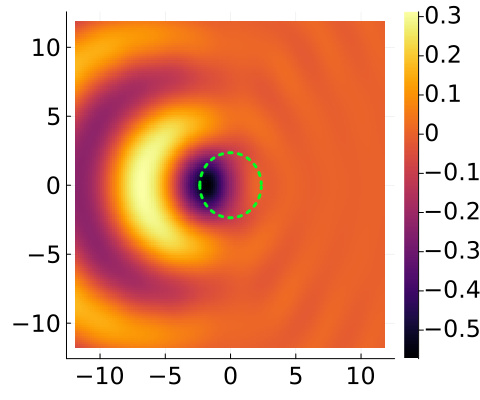

In [7]:
pl = heatmap(x_array,y_array,A[3],
            tickfontsize=16,
            size=(480,400),
            right_margin=0.75Plots.cm)

plot!(pl,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(pl,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)


In [12]:
# Isolate the lhs and rhs of the body to only 
lx = A[6];
rx = A[7];
ly = A[8];
ry = A[9];

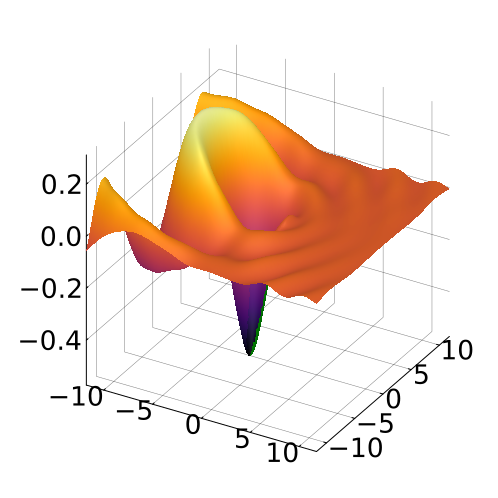

In [13]:
pl = surface(x_array[lx:rx],y_array[ly:ry],proj_hr[ly:ry,lx:rx],colorbar=false,gridalpha=0.5,
            c=cgrad(["green","green"]),
            margin=-1Plots.cm,size=(500,500),tickfontsize=18)

surface!(pl,x_array,y_array,outer_hr,colorbar=false,gridalpha=0.5)

move through time to get a better view of the green part

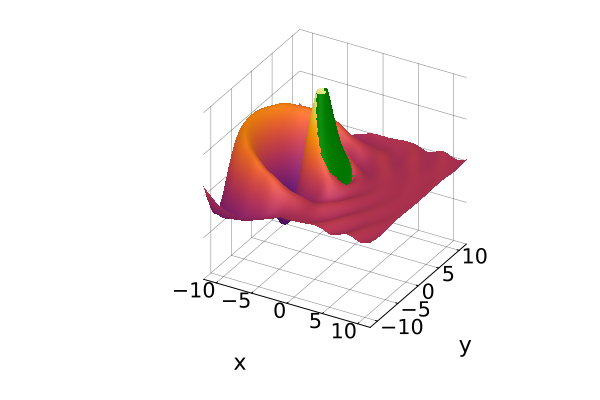

In [ ]:
i=1
pl = surface(x_array,y_array,outer_hr*cos(pi*i)+outer_hi*sin(pi*i),colorbar=false,gridalpha=0.5,zlims=[-0.5,0.5])

surface!(pl, x_array[lx:rx],y_array[ly:ry],proj_hr[ly:ry,lx:rx]*cos(pi*i)+proj_hi[ly:ry,lx:rx]*sin(pi*i),colorbar=false,gridalpha=0.5,
            c=cgrad(["green","green"]),#camera=(0,90),
            zaxis=false,tickfontsize=14,
            xlabel="x",ylabel="y",labelfontsize=15)


---

## Animations



In [ ]:
anim = @animate for i in 0:0.1:2
    pl = surface(x_array,y_array,A[3]*cos(pi*i)+A[4]*sin(pi*i),colorbar=false,gridalpha=0.5,zlims=[-3,3]
                ,tickfontsize=14,xlabel="x",ylabel="y",labelfontsize=15,zlabel="Wave field")
end

Animation("/tmp/jl_wSDfs8", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000012.png", "000013.png", "000014.png", "000015.png", "000016.png", "000017.png", "000018.png", "000019.png", "000020.png", "000021.png"])

┌ Info: Saved animation to /home/daire/two_dim/2d_code/elliptical_source/siam_talk_subcrit_proj.gif
└ @ Plots /home/daire/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/home/daire/two_dim/2d_code/elliptical_source/siam_talk_subcrit_proj.gif")
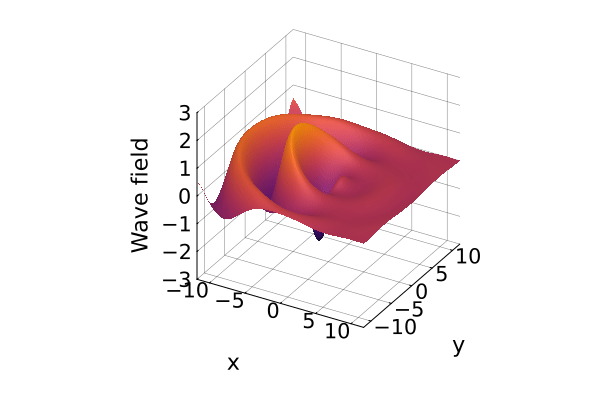

In [27]:
gif(anim, "siam_talk_subcrit_proj.gif")

In [24]:
anim = @animate for i in 0:0.1:2
    pl = surface(x_array,y_array,A[3]*cos(pi*i)+A[4]*sin(pi*i),colorbar=false,gridalpha=0.5,
                zlims=[-3,3])

    surface!(pl, x_array[lx:rx],y_array[ly:ry],proj_hr[ly:ry,lx:rx]*cos(pi*i) + proj_hi[ly:ry,lx:rx]*sin(pi*i),colorbar=false,gridalpha=0.5,
                c=cgrad(["green","green"]),camera=(0,90),
                zaxis=false,margin=-1Plots.cm,size=(350,350),tickfontsize=14,
                xlabel="x",ylabel="y",labelfontsize=15)
end


Animation("/tmp/jl_FQNx74", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000012.png", "000013.png", "000014.png", "000015.png", "000016.png", "000017.png", "000018.png", "000019.png", "000020.png", "000021.png"])

┌ Info: Saved animation to /home/daire/two_dim/2d_code/elliptical_source/siam_talk_subcrit_plan.gif
└ @ Plots /home/daire/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/home/daire/two_dim/2d_code/elliptical_source/siam_talk_subcrit_plan.gif")
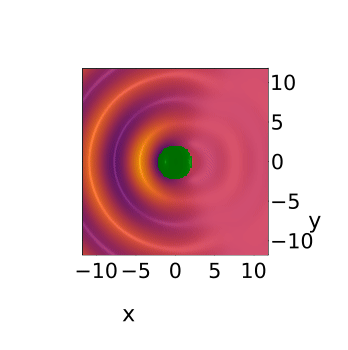

In [25]:
gif(anim, "siam_talk_subcrit_plan.gif")